In [1]:
import spectral.io.envi as envi
import spectral
import numpy as np
import matplotlib.pyplot as plt

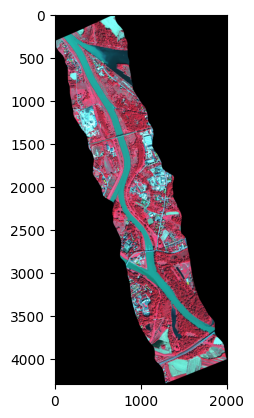

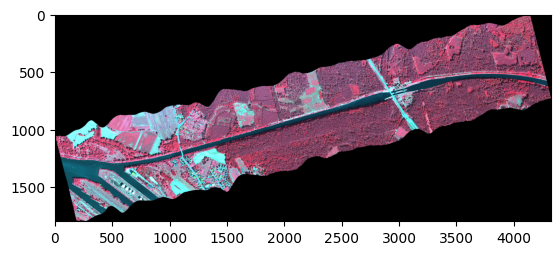

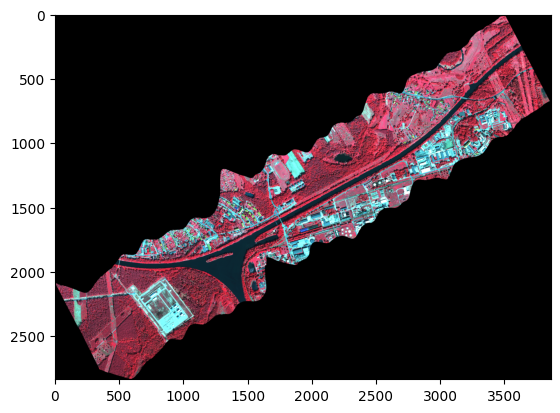

In [2]:
images = [
    envi.open('data/221000_Odra_HS_Blok_A_008_VS_join_atm.hdr'),
    envi.open('data/221000_Odra_HS_Blok_A_013_VS_join_atm.hdr'),
    envi.open('data/221000_Odra_HS_Blok_A_015_VS_join_atm.hdr')
]

def get_band(target_wv, list):
    bands = np.array([abs(float(wv) - target_wv) for wv in list])
    return np.argmin(bands)


for image in images: 
    wavelengths = image.metadata.get('wavelength')
    spectral.imshow(image, (get_band(750, wavelengths), get_band(630, wavelengths), get_band(525, wavelengths)), stretch=0.02)


/var/folders/d9/3r59pgz17qxdqxqpp6mkwn040000gn/T/ipykernel_42927/3843883645.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


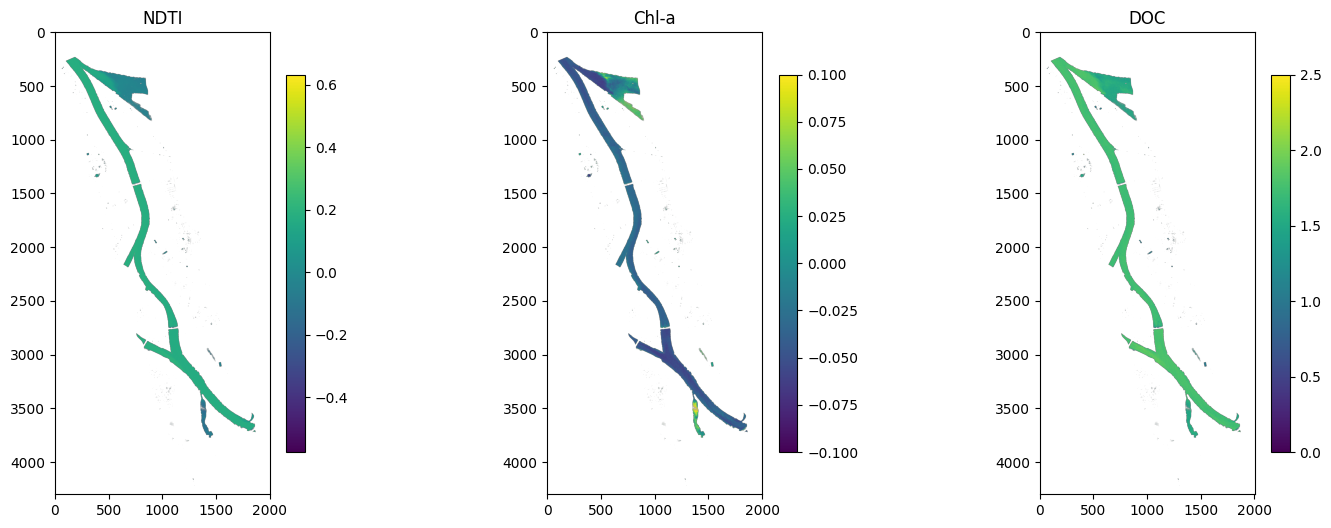

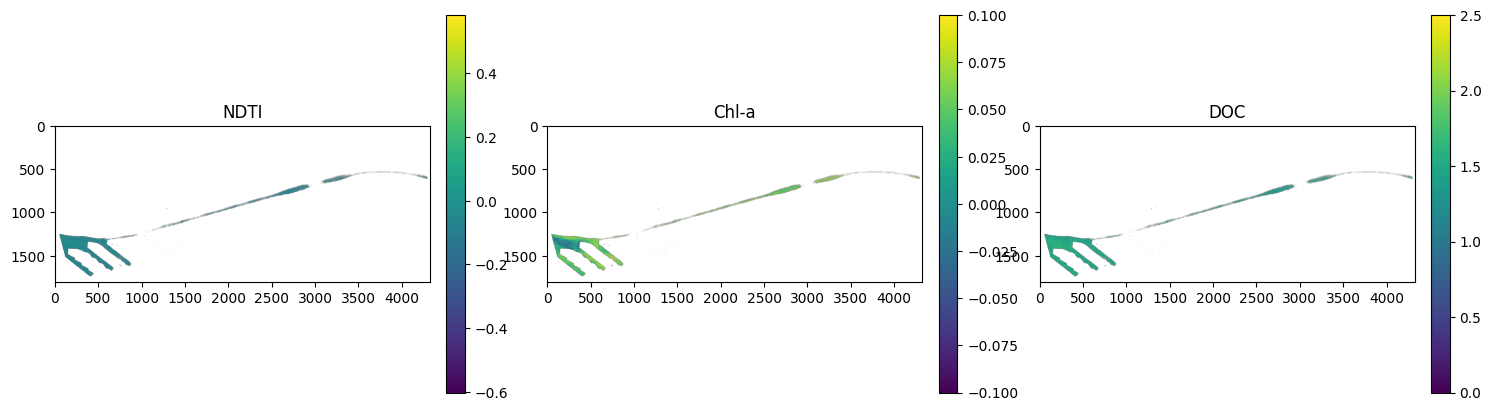

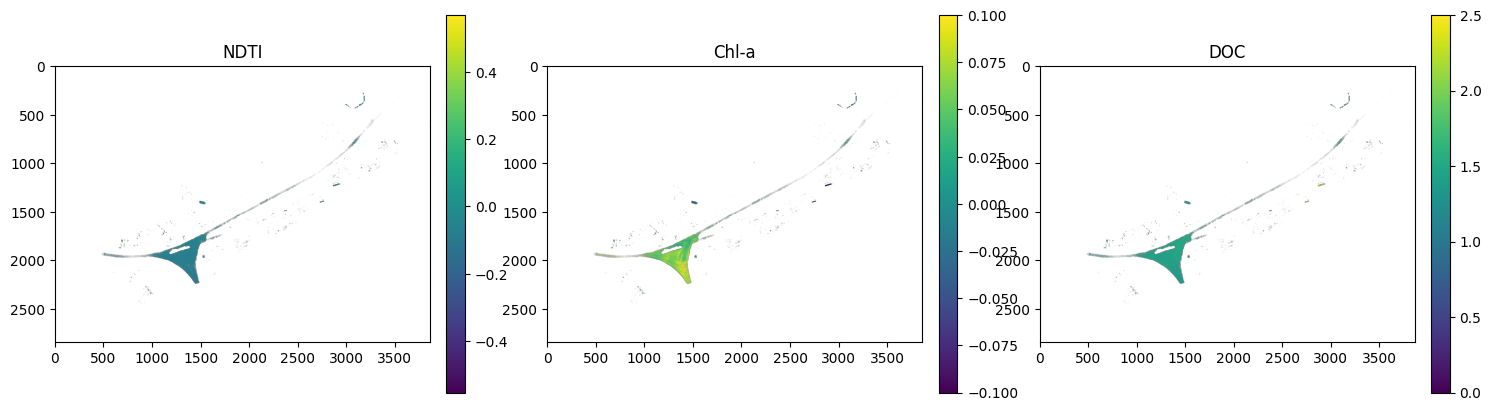

In [3]:
for ix, image in enumerate(images):
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    wvl = [float(w) for w in image.metadata.get('wavelength')]
    

    red = image.read_band(get_band(665, wavelengths)).astype(float)
    red_edge = image.read_band(get_band(705, wvl)).astype(float)

    green = image.read_band(get_band(525, wavelengths)).astype(float)
    blue = image.read_band(get_band(450, wavelengths)).astype(float)
    nir = image.read_band(get_band(850, wvl)).astype(float)

    ndwi = (green - nir) / (green + nir + 1e-8)

    valid_mask = (ndwi > 0)

    ndti = (red - green) / (red + green + 1e-8)
    ndti_masked = np.where(valid_mask, ndti, np.nan)

    chla = (red_edge - red) / (red_edge + red + 1e-8)
    chla_masked = np.where(valid_mask, chla, np.nan)

    doc = green / (blue + 1e-8)
    doc_masked = np.where(valid_mask, doc, np.nan)

    first = ax[0].imshow(ndti_masked)
    ax[0].set_title('NDTI')
    plt.colorbar(first, ax=ax[0], fraction=0.046, pad=0.04)

    second = ax[1].imshow(chla_masked, vmin=-0.1, vmax=0.1)
    ax[1].set_title('Chl-a')
    plt.colorbar(second, ax=ax[1], fraction=0.046, pad=0.04)

    third = ax[2].imshow(doc_masked, vmin=0, vmax=2.5)
    ax[2].set_title('DOC')
    plt.colorbar(third, ax=ax[2], fraction=0.046, pad=0.04)

    fig.show()

In [4]:
import pystac_client
import planetary_computer
import os
import rasterio
from rasterio.mask import mask
from rasterio.merge import merge
from shapely.geometry import box
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
import pyproj
from shapely.ops import transform

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace
)

images_boxes = [
    [18.136719, 50.323520, 18.164953, 50.362143],
    [18.144759, 50.353611, 18.205590, 50.369703],
    [18.241863, 50.343192, 18.296279, 50.368581]
]

target_10m_assets = ["B05"]

for ix, bbox_coords in enumerate(images_boxes):
    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox_coords,
        datetime="2025-06-15/2025-06-19",
        query={"eo:cloud_cover": {"lt": 10}}
    )

    items = list(search.get_items())
    if not items: continue

    target_time = items[0].datetime
    matching_items = [i for i in items if i.datetime == target_time]
    
    aoi_geom = box(*bbox_coords)
    scene_dir = f"sentinel_10m_cropped/box_{ix}"
    os.makedirs(scene_dir, exist_ok=True)

    for asset_key in target_10m_assets:
        file_path = os.path.join(scene_dir, f"{asset_key}.tif")

        if len(matching_items) == 1:
            url = matching_items[0].assets[asset_key].href
            with rasterio.open(url) as src:
                project = pyproj.Transformer.from_crs("EPSG:4326", src.crs, always_xy=True).transform
                aoi_projected = transform(project, aoi_geom)
                
                out_image, out_transform = mask(src, [aoi_projected], crop=True)
                out_meta = src.meta.copy()
                out_meta.update({
                    "height": out_image.shape[1],
                    "width": out_image.shape[2],
                    "transform": out_transform
                })
                with rasterio.open(file_path, "w", **out_meta) as dest:
                    dest.write(out_image)

        else:
            vrt_list = []
            opened_files = []
            for item in matching_items:
                src = rasterio.open(item.assets[asset_key].href)
                opened_files.append(src)
                vrt = WarpedVRT(src, crs='EPSG:4326', resampling=Resampling.bilinear)
                vrt_list.append(vrt)

            mosaic, out_trans = merge(vrt_list)
            
            merged_meta = vrt_list[0].meta.copy()
            merged_meta.update({
                "driver": "GTiff",
                "height": mosaic.shape[1],
                "width": mosaic.shape[2],
                "transform": out_trans,
                "crs": "EPSG:4326"
            })

            with rasterio.io.MemoryFile() as memfile:
                with memfile.open(**merged_meta) as dataset:
                    dataset.write(mosaic)
                    out_image, out_transform = mask(dataset, [aoi_geom], crop=True)
                
                final_meta = merged_meta.copy()
                final_meta.update({
                    "height": out_image.shape[1],
                    "width": out_image.shape[2],
                    "transform": out_transform
                })
                
                with rasterio.open(file_path, "w", **final_meta) as dest:
                    dest.write(out_image)

            for v in vrt_list: v.close()
            for f in opened_files: f.close()

/Users/jklimek/Desktop/AGH/RSIA/lab_3/lib/python3.13/site-packages/pystac_client/item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(
/Users/jklimek/Desktop/AGH/RSIA/lab_3/lib/python3.13/site-packages/pystac_client/item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(
/Users/jklimek/Desktop/AGH/RSIA/lab_3/lib/python3.13/site-packages/pystac_client/item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


In [14]:
b05_bands = [
    "sentinel_10m_cropped/box_0/B05.tif",
    "sentinel_10m_cropped/box_1/B05.tif",
    "sentinel_10m_cropped/box_2/B05.tif",
]

references = [
    "sentinel_10m_cropped/box_0/B04.tif",
    "sentinel_10m_cropped/box_1/B04.tif",
    "sentinel_10m_cropped/box_2/B04.tif", 
]

def upscale_band_to_10m(path_to_b05, reference_10m_path, output_path):
    with rasterio.open(reference_10m_path) as ref:
        target_meta = ref.meta.copy()
        target_shape = (ref.height, ref.width)
        target_transform = ref.transform

    with rasterio.open(path_to_b05) as src:
        data = src.read(
            1,
            out_shape=target_shape,
            resampling=Resampling.bilinear
        )
        
        target_meta.update({
            "driver": "GTiff",
            "height": target_shape[0],
            "width": target_shape[1],
            "transform": target_transform,
            "crs": src.crs
        })

        with rasterio.open(output_path, "w", **target_meta) as dst:
            dst.write(data, 1)
    
for file, reference in zip(b05_bands, references):
    segments = file.split("/")
    output_name = "/".join(segments[:2]) + "/" + segments[2].split(".")[0] + "_10m.tif"
    upscale_band_to_10m(file, reference, output_name)

In [22]:
def pstretch(arr, lo=2, hi=98):
    a = arr.astype(np.float32)
    v = a[np.isfinite(a) & (a > 0)]
    if v.size == 0:
        return np.zeros_like(a)
    lo_v, hi_v = np.percentile(v, [lo, hi])
    return np.clip((a - lo_v) / (hi_v - lo_v + 1e-9), 0, 1)

def load_sentinel(bands):
    loaded_bands = []

    for key in ("B", "G", "R", "RE", "NIR"):
        with rasterio.open(bands[key]) as src:
            loaded_bands.append(src.read(1))

    return np.stack([b for b in loaded_bands], axis=-1)

scene_08_sentinel_bands = {
    "R": "sentinel_10m_cropped/box_0/B04.tif",
    "G": "sentinel_10m_cropped/box_0/B03.tif",
    "B": "sentinel_10m_cropped/box_0/B02.tif",
    "RE": "sentinel_10m_cropped/box_0/B05_10m.tif",
    "NIR": "sentinel_10m_cropped/box_0/B08.tif"
}

scene_13_sentinel_bands = {
    "R": "sentinel_10m_cropped/box_1/B04.tif",
    "G": "sentinel_10m_cropped/box_1/B03.tif",
    "B": "sentinel_10m_cropped/box_1/B02.tif",
    "RE": "sentinel_10m_cropped/box_1/B05_10m.tif",
    "NIR": "sentinel_10m_cropped/box_1/B08.tif"
}

scene_15_sentinel_bands = {
    "R": "sentinel_10m_cropped/box_2/B04.tif",
    "G": "sentinel_10m_cropped/box_2/B03.tif",
    "B": "sentinel_10m_cropped/box_2/B02.tif",
    "RE": "sentinel_10m_cropped/box_2/B05_10m.tif",
    "NIR": "sentinel_10m_cropped/box_2/B08.tif"
}

sentinel_imagery = [
    scene_08_sentinel_bands,
    scene_13_sentinel_bands,
    scene_15_sentinel_bands,
]

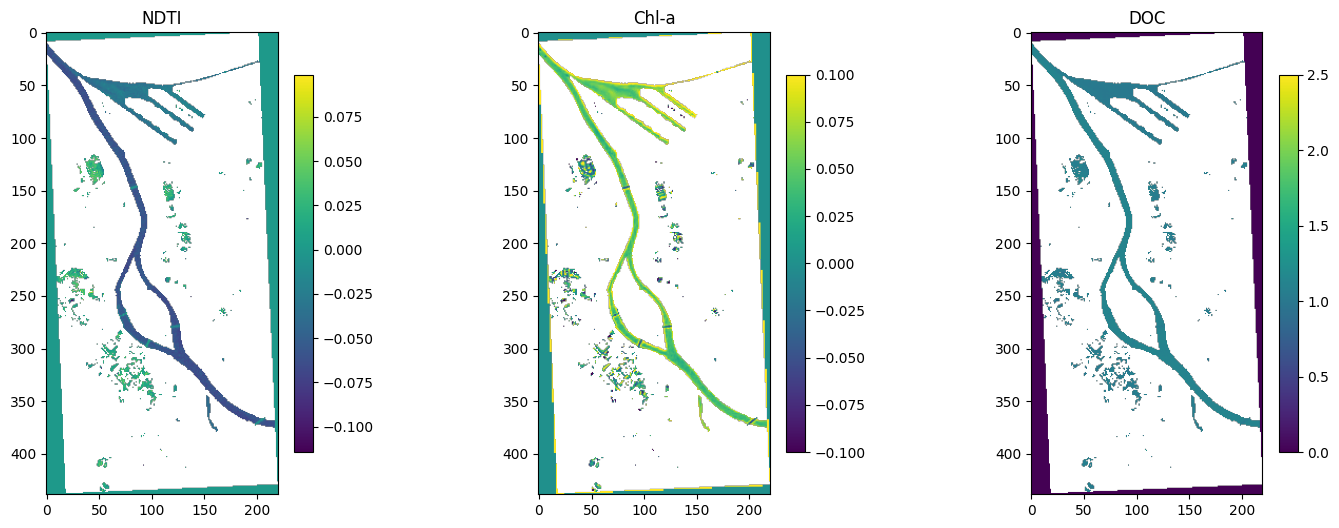

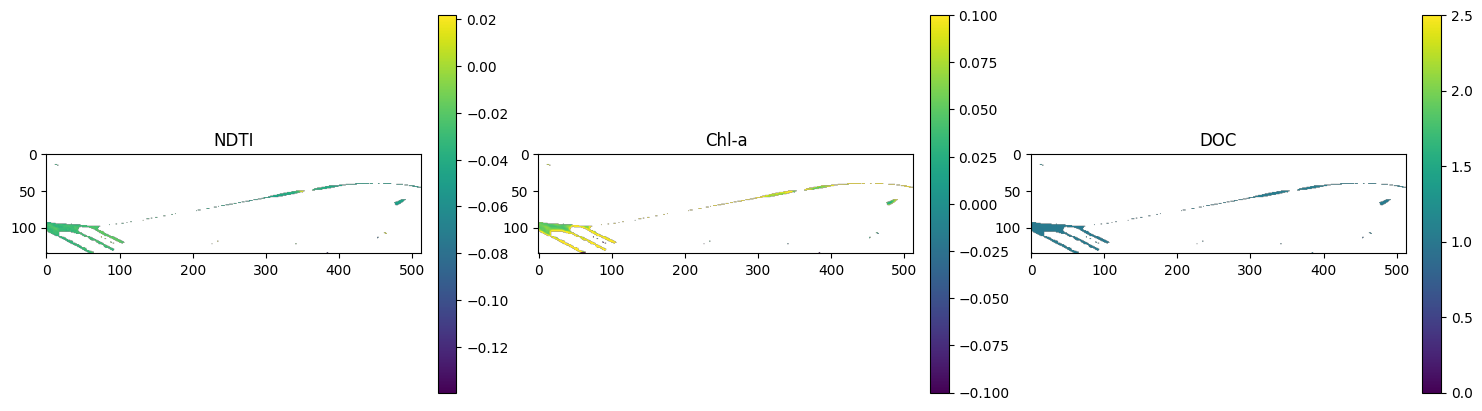

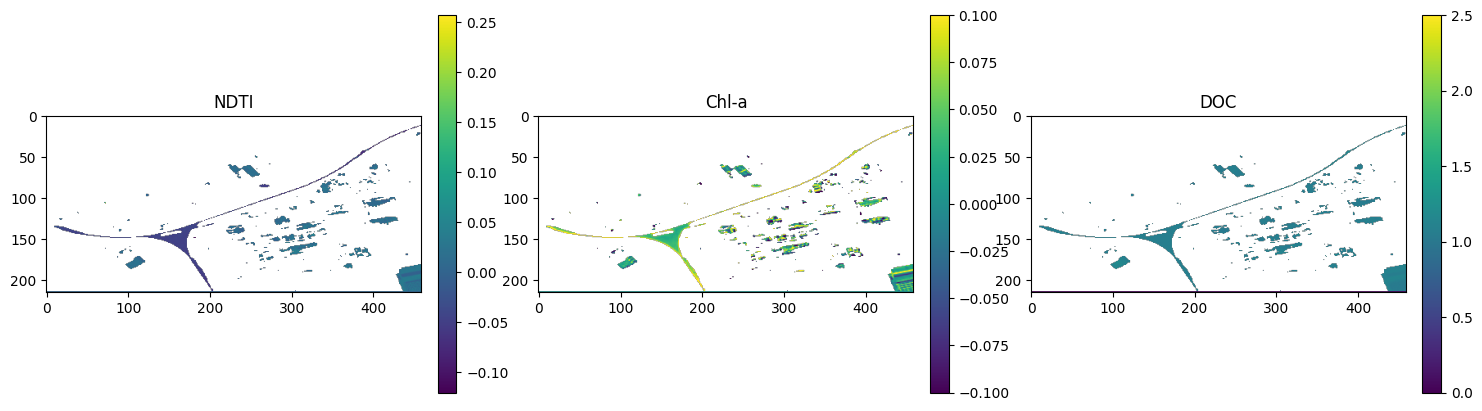

In [38]:
for image in sentinel_imagery:
    s2_data = load_sentinel(image)


    blue = s2_data[:, :, 0] / 10000
    green = s2_data[:, :, 1] / 10000
    red = s2_data[:, :, 2] / 10000
    red_edge = s2_data[:, :, 3] / 10000
    nir = s2_data[:, :, 4] / 10000

    ndwi_s2 = (green - nir) / (green + nir + 1e-8)
    valid_mask_s2 = (ndwi_s2 > -0.1)

    ndti_s2 = (red - green) / (red + green + 1e-8)
    ndti_s2_masked = np.where(valid_mask_s2, ndti_s2, np.nan)

    chla_s2 = (red_edge - red) / (red_edge + red + 1e-8)
    chla_s2_masked = np.where(valid_mask_s2, chla_s2, np.nan)

    doc_s2 = green / (blue + 1e-8)
    doc_s2_masked = np.where(valid_mask_s2, doc_s2, np.nan)

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    first = ax[0].imshow(ndti_s2_masked)
    ax[0].set_title('NDTI')
    plt.colorbar(first, ax=ax[0], fraction=0.046, pad=0.04)

    second = ax[1].imshow(chla_s2_masked, vmin=-0.1, vmax=0.1)
    ax[1].set_title('Chl-a')
    plt.colorbar(second, ax=ax[1], fraction=0.046, pad=0.04)

    third = ax[2].imshow(doc_s2_masked, vmin=0, vmax=2.5)
    ax[2].set_title('DOC')
    plt.colorbar(third, ax=ax[2], fraction=0.046, pad=0.04)

    plt.show()
